In [1]:
%load_ext autoreload
%autoreload 2

#import argparse
from   astropy import table
from   astropy.io import ascii, fits
from   astropy.coordinates import SkyCoord
from   astropy import units as u
from astropy.cosmology import Planck18

import copy
import corner
#import dynesty
import logging
#from   misc import bcolors
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from   plotsettings import *
from   prospect.sources.constants import cosmo
from   prospect.fitting import fit_model, lnprobfn
from sedpy.observate import load_filters
import prospect.io.write_results as writer
import prospect.io.read_results as reader
#from   prospect.likelihood import lnlike_spec, lnlike_phot, write_log, chi_spec, chi_phot
#from   prospect.models import priors
#from   prospect.models.templates import TemplateLibrary
from   routines_prospector import *
#import sfdmap
import sys
import time
import pandas as pd
import extinction
import vals

In [3]:
obj_name='AT2024wpp'
default_z=False
redshifts=vals.redshifts
spec_file={'AT2023hkw': 'data/AT2023hkw/AT2023hkw_Keck.txt', 'AT2023fhn': 'data/AT2023fhn/AT2023fhn_LRIS.txt',
           'AT2022abfc': 'data/AT2022abfc/AT2022abfc_GMOS_stack.txt', 'AT2023vth': 'data/AT2023vth/AT2023vth_GMOS2.txt',
          'AT2024aehp': 'data/AT2024aehp/AT2024aehp_binospec.txt'}

# Optical bands: all from LS, vth from PS database lookup
# SNR limit of 5 for WISE
# HST from Chrimes paper
# GALEX from GPhoton, note WISE uses Vega system
# WISE from LS DR10 except for 23vth.
# USED WISE 2012 for 23vth




galaxy_mags={'AT2022abfc':[19.057, 18.124, 17.698,  17.464,
                            21.550,
                            17.356, 17.568, 15.875],
               'AT2023fhn': [19.452, 18.912, 18.606,  18.566,
                            20.60, 20.40, 19.34, 18.93, 18.84, 18.68,
                            20.913,
                            18.796, 18.755],
              'AT2023hkw': [20.706, 19.669, 18.996,
                            21.898,
                            18.833, 19.097],
               'AT2023vth': [19.54400062561035-0.11439372640168785, 18.888399124145508-0.11439372640168785, 18.484600067138672-0.11439372640168785, 18.293399810791016-0.11439372640168785,
                            21.601,
                            17.110+2.699,16.831+3.339],
             'AT2024qfm':[20.530, 19.706, 19.135,
                            19.156, 19.218],
            'AT2024aehp':[20.881, 20.454, 20.240,  20.232,
                            22.158, 21.902,
                            20.761, 20.468],
             'AT2024wpp':[22.115, 21.846, 21.859,
                          21.073, 21.5,
                          20.213, 20.294, 20.161,
                          19.879, 19.677, 19.74, 
                          19.481, 19.697, 19.479,
                          19.360,
                            20.335, 20.264],
}
galaxy_mag_err={'AT2022abfc':[0.002,  0.001, 0.001, 0.002,
                            0.310,
                            0.007, 0.015, 0.073],
               'AT2023fhn': [0.006,  0.006, 0.009, 0.009,
                            0.07, 0.03, 0.01, 0.01, 0.01, 0.02,
                            0.200,
                          0.024,0.051],
                'AT2023hkw': [0.014, 0.012, 0.010,
                            0.086,
                            0.022, 0.051],
               'AT2023vth': [0.019, 0.012, 0.008, 0.014,
                            0.274,
                            0.192, 0.380],
               'AT2024qfm':[0.007,  0.006, 0.007,
                            0.028, 0.067],
                'AT2024aehp':[0.009,  0.009, 0.013, 0.020,
                            0.181, 0.115,
                            0.117, 0.206],
                'AT2024wpp':[0.217, 0.210,  0.179,
                             0.453, 0.13,
                             0.07, 0.09, 0.05,
                             0.1, 0.05, 0.17,
                             0.11, 0.12, 0.05,
                             0.05,
                            0.1, 0.20],
}

b_v={'AT2022abfc': 0.0298, 'AT2023hkw': 0.0111, 'AT2023fhn': 0.0254, 'AT2023vth': 0.1801,'AT2024qfm':0.0421, 'AT2024wpp':0.0245, 'AT2024aehp':0.0245}
logz={'AT2023vth': -0.6, 'AT2024wpp':-0.4, 'AT2023fhn': -0.2702932382299956,
'AT2024aehp': -0.604597852295, 'AT2024qfm': -0.20465248279999798, 'AT2022abfc': 0.05491899643000091, 'AT2023hkw': 0.03484174200000151}

bands={'AT2022abfc':['sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0',
                   'galex_NUV',
                    'wise_w1', 'wise_w2', 'wise_w3'],
       'AT2023fhn':['sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0',
                    'wfc3_uvis_f225w', 'wfc3_uvis_f336w', 'wfc3_uvis_f555w','wfc3_uvis_f763m', 'wfc3_uvis_f814w', 'wfc3_uvis_f845m',
                   'galex_NUV',
                    'wise_w1', 'wise_w2'],
      'AT2023hkw':['sdss_g0', 'sdss_r0','sdss_z0',
                   'galex_NUV',
                    'wise_w1', 'wise_w2'],
        'AT2023vth':['panstarrs_g', 'panstarrs_r', 'panstarrs_i', 'panstarrs_z',
                   'galex_NUV',
                    'wise_w1', 'wise_w2'],
       'AT2024qfm':['sdss_g0', 'sdss_r0', 'sdss_z0',
                    'wise_w1', 'wise_w2'],
      'AT2024aehp':['sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0',
                    'galex_FUV', 'galex_NUV', 
                    'wise_w1', 'wise_w2'],
    'AT2024wpp':['uvot_w2', 'uvot_m2', 'uvot_w1',
                  'bessell_u', 'sdss_u0',
                  'sdss_g0', 'sdss_g0', 'sdss_g0',
                  'bessell_r', 'sdss_r0',  'sdss_r0',
                  'bessell_i', 'sdss_i0',  'sdss_i0',
                  'sdss_z0',
                    'wise_w1', 'wise_w2']}






In [4]:
# Set initial values

In [5]:
run_params = {}

In [6]:
# Object properties

In [7]:
run_params['zred']                    = redshifts[obj_name]
run_params['ldist']                   = Planck18.luminosity_distance(run_params['zred']).value
run_params['objname']                 = obj_name

In [8]:
# SED parameters

In [9]:
run_params['err_floor']               = 0.05

In [10]:
# Sampler

In [11]:
run_params["nwalkers"]                = 128
run_params["niter"]                   = 512
run_params["nburn"]                   = [16, 32, 64]

run_params["nested_method"]           = "acceptance-walk"
run_params["nlive_init"]              = 400
run_params["nlive_batch"]             = 400
run_params["nested_dlogz_init"]       = 0.5
run_params["nested_posterior_thresh"] = 0.5
run_params["nested_rwalks"]           = 48
run_params['nested_weight_kwargs']    = {'pfrac': 1.0}
run_params['nested_maxcall']          = 3500000
run_params['nested_maxcall_init']     = 2500000
run_params['nested_maxbatch']         = None
run_params['nested_first_update']     = {'min_ncall': 20000, 'min_eff': 7.5}

In [12]:
EMCEE   = False
DYNESTY = True
OPTIMIZE= False

run_params["optimize"]          = OPTIMIZE
run_params["emcee"]             = EMCEE
run_params["dynesty"]           = DYNESTY
results_type                    = 'emcee' if EMCEE else 'dynesty' if DYNESTY else 'None'
hfile                           = "{name}_prospector_{sampler}.h5".format(name=run_params['objname'], sampler=results_type)

In [13]:
## Photometry

Spectral resolution
* LRIS 400/3400 and 400/8500 have a FWHM of 6.5-7.1 AA and 6.9 AA, respectively (FWHM).
* The average FWHM is 6.8 AA. sigma = FWHM / 2.355. -> Mean sigma is 2.89 AA
* Assuming GMOS b600/r400 grating, R ~ 1700, which at 5000 AA gives a FWHM of ~ 3 AA
* Assuming Keck/Deimos 600 ZD grating, FWHM ~ 3.5 AA

In [14]:
sigma = {'AT2023fhn': 6.8/2.355, 'AT2022abfc': 3/2.355, 'AT2023vth': 3/2.355, 'AT2023hkw': 3.5/2.355}

In [15]:
# SED modelling

In [16]:
mag=np.array(galaxy_mags[obj_name])

if obj_name=='AT2023fhn':
    header=166
else:
    header=0
    


# Milky Way Extinction for photometry
a_v = b_v[obj_name]*3.1

filters = load_filters([f"{b}" for b in bands[obj_name]])
phot_wave   = [f.wave_effective for f in filters]

mag-=extinction.fm07(np.array(phot_wave), a_v)
print(mag)



[21.89226996 21.60395522 21.6808979  20.95476033 21.38111301 20.11952871
 20.20052871 20.06752871 19.8186307  19.61212654 19.67512654 19.43938969
 19.65004896 19.43204896 19.32595247 20.33206391 20.26228671]


In [17]:




phot_masks={'AT2022abfc': np.array([True]*8), 'AT2023hkw': np.array([True]*6),
        'AT2023fhn': np.array([True]*13), 'AT2023vth':  np.array([True]*7), 'AT2024qfm':  np.array([True]*5), 'AT2024aehp':  np.array([True]*8),
        'AT2024wpp':  np.array([True]*17)}



maggies = np.power(10, -0.4*mag)
magerr = np.array([0.05 for b in bands[obj_name]])
magerr = np.hypot(magerr, 0.05)

obs = dict(wavelength=None, spectrum=None, unc=None, redshift=redshifts[obj_name],
           maggies=maggies, maggies_unc=magerr * maggies / 1.086, filters=filters)



obs["phot_mask"] = phot_masks[obj_name]
obs["phot_wave"]=phot_wave


obs = fix_obs(obs)
obs

{'wavelength': None,
 'spectrum': None,
 'unc': None,
 'redshift': 0.0868,
 'maggies': array([1.75021748e-09, 2.28253746e-09, 2.12637980e-09, 4.15045652e-09,
        2.80255921e-09, 8.95753507e-09, 8.31358836e-09, 9.39698464e-09,
        1.18181016e-08, 1.42938554e-08, 1.34880567e-08, 1.67588466e-08,
        1.38032202e-08, 1.68725381e-08, 1.86045433e-08, 7.36502857e-09,
        7.85389907e-09]),
 'maggies_unc': array([1.13958623e-10, 1.48618574e-10, 1.38450974e-10, 2.70240879e-10,
        1.82477774e-10, 5.83235155e-10, 5.41307063e-10, 6.11848210e-10,
        7.69489849e-10, 9.30688956e-10, 8.78222501e-10, 1.09118730e-09,
        8.98743151e-10, 1.09858988e-09, 1.21136268e-09, 4.79545271e-10,
        5.11376178e-10]),
 'filters': [<class 'sedpy.observate.Filter'>(uvot_w2),
  <class 'sedpy.observate.Filter'>(uvot_m2),
  <class 'sedpy.observate.Filter'>(uvot_w1),
  <class 'sedpy.observate.Filter'>(bessell_u),
  <class 'sedpy.observate.Filter'>(sdss_u0),
  <class 'sedpy.observate.Filter'

In [18]:
#Fitting to Spectra

#spec = pd.read_csv(spec_file[obj_name], sep=' +', engine='python', names=['wavelen', 'flux', 'flux_unc'], header=0)
#spec=spec.loc[pd.notna(spec['flux'])]

#spec.loc[:,'flux_jy_cal']=(np.array(spec['flux'])*u.erg/u.s/u.cm**2/u.AA).to(u.Jy, equivalencies=u.spectral_density(np.array(spec['wavelen'])*u.AA)).value
#spec.loc[:, 'flux_jy_unc']=1e23*spec.loc[:, 'flux_unc']*np.power(spec.loc[:, 'wavelen'], 2)/(3*10**18)

bounds={'AT2022abfc': (4000, 8000), 'AT2023fhn': (3000, 6650), 'AT2023hkw': (3400, 8000), 'AT2023vth': (5000, 8000),
       'AT2024aehp': (3100, 7500)}

#input_data=spec

#wave_rest = input_data.loc[:, 'wavelen'] / (1+redshifts[obj_name])

#mask = ((input_data['flux_jy_unc'] > 0) &
#                (input_data['flux_jy_cal'] != 0) &
#                (input_data['wavelen'] < 8325) &
#                (wave_rest > bounds[obj_name][0]) &
#                (wave_rest < bounds[obj_name][1]) &
#                (np.abs(wave_rest-5892.9) > 25) &
#                (np.abs(wave_rest-3935.0) > 10) &
#                (np.abs(wave_rest-3969.0) > 20)
#                )

phot_filter=input_data.loc[mask]

mask_telluric = (np.abs(wave_rest[mask] - 6873) > 15) & (np.abs(wave_rest[mask] - 7610) > 20)

obs = dict(wavelength=np.array(phot_filter['wavelen']), spectrum=np.array(phot_filter['flux_jy_cal'])/3631, unc=np.array(phot_filter['flux_jy_unc']/3631), redshift=redshifts[obj_name],
           maggies=maggies, maggies_unc=magerr * maggies / 1.086, filters=filters, mask=np.array(mask_telluric),
          phot_mask=phot_masks[obj_name], phot_wave=phot_wave)

obs

NameError: name 'input_data' is not defined

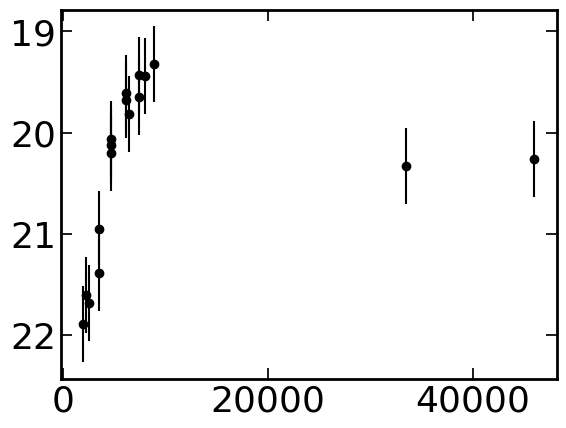

In [20]:
# Show the observaations
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
                    
ax.plot(obs["phot_wave"], np.log10(obs["maggies"])/-0.4, linestyle="", marker="o", color="k")
ax.errorbar(obs["phot_wave"],  np.log10(obs["maggies"])/-0.4, np.log(10)*np.divide(obs["maggies_unc"], obs["maggies"])/0.4, linestyle="", color="k", zorder=10)
#ax.plot(obs["wavelength"], np.log10(obs["spectrum"])/-0.4)
ax.invert_yaxis()
#plt.savefig('figures/{}_input.png'.format(obj_name))

In [27]:
from prospect.models.templates import TemplateLibrary
from prospect.models import PolySpecModel, priors

model_params = TemplateLibrary["parametric_sfh"]
model_params.update(TemplateLibrary["nebular"])

# --- Mass ---
model_params["mass"]["init"] = 1e10
model_params["mass"]["disp_floor"] = 1e6
model_params["mass"]["prior"] = priors.LogUniform(mini=1e5, maxi=1e13)
    
# Redshift and luminosity distance
model_params["lumdist"] = {"N": 1, "isfree": False, "init": (Planck18.luminosity_distance(z=redshifts[obj_name])).to(u.Mpc).value, "units":"Mpc"}

# --- Use C3K everywhere ---
model_params["use_wr_spectra"] = dict(N=1, isfree=False, init=0)
model_params["logt_wmb_hot"]   = dict(N=1, isfree=False, init=np.log10(5e4))

# --- SFH ---

model_params["sfh"]['init'] = 4
model_params["sfh"]['isfree'] = False

model_params["tage"]["prior"] = priors.LogUniform(mini=0.001, maxi=13.8) # Gyr
model_params["tage"]["init"] = 1
model_params["tage"]["disp_floor"] = 0.1

model_params["tau"]["prior"] = priors.LogUniform(mini=1e-1, maxi=1e2) # Gyr
model_params["tau"]["init"] = 1
model_params["tau"]["disp_floor"] = 0.1


model_params["logzsol"]["isfree"]=False
if default_z:
    model_params["logzsol"]["init"] = -0.2
else:
    model_params["logzsol"]["init"] = logz[obj_name]

#model_params["logzsol"]["isfree"]=True
#model_params["logzsol"]["prior"] = priors.TopHat(mini=-3.5, maxi=0.5)


model_params["zred"]["init"] = redshifts[obj_name]
model_params["zred"]['isfree'] = False
#model_params['nebemlineinspec']["init"] = False
#model_params['nebemlineinspec']["isfree"] = False

model_params['gas_logu']['isfree'] = True

model_params['gas_logz']['isfree'] = True
_ = model_params["gas_logz"].pop("depends_on")


#model_params.update(TemplateLibrary['spectral_smoothing'])
#model_params["sigma_smooth"]["prior"] = priors.TopHat(mini=50.0, maxi=300.0)

#model_params.update(TemplateLibrary['nebular_marginalization'])

#model_params['eline_prior_width']['init'] = 10.0
#model_params['use_eline_prior']['init'] = True

            # only marginalize over a few (strong) emission lines

to_fit = ['Ba-gamma 4341',
            'Ba-beta 4861', '[O III] 4959', '[O III] 5007',
            '[N II] 6548', 'Ba-alpha 6563', '[N II] 6584', 
            '[S II] 6716', '[S II] 6731'
            ]
#model_params['elines_to_fit']['init'] = to_fit

#model_params.update(TemplateLibrary['optimize_speccal'])
#model_params['spec_norm']['isfree'] = False
#model_params["polyorder"]["init"] = 12

#model_params['nsigma_outlier_spec'] = dict(N=1, isfree=False, init=50.)
#model_params['f_outlier_spec'] = dict(N=1, isfree=True, init=0.01,
#                                              prior=priors.TopHat(mini=1e-5, maxi=0.1))
model_params['nsigma_outlier_phot'] = dict(N=1, isfree=False, init=50.)
model_params['f_outlier_phot'] = dict(N=1, isfree=False, init=0.0,
                                              prior=priors.TopHat(mini=0, maxi=0.5))
#model_params['spec_jitter'] = dict(N=1, isfree=True, init=1.0,
#                                           prior=priors.TopHat(mini=1.0, maxi=3.0))
# For Chabrier, want imf_type = 1, dust_type=2

model_params["imf_type"]["init"] = 1
model_params["dust_type"]["init"] = 2
model_params["dust2"]["prior"] = priors.TopHat(mini=0.0, maxi=8.0)
model_params["dust2"]["init"] = 0.05  # dust absorption



model = PolySpecModel(model_params)
model



:::::::
<class 'prospect.models.sedmodel.PolySpecModel'>

Free Parameters: (name: prior) 
-----------
  mass: <class 'prospect.models.priors.LogUniform'>(mini=100000.0,maxi=10000000000000.0)
  dust2: <class 'prospect.models.priors.TopHat'>(mini=0.0,maxi=8.0)
  tage: <class 'prospect.models.priors.LogUniform'>(mini=0.001,maxi=13.8)
  tau: <class 'prospect.models.priors.LogUniform'>(mini=0.1,maxi=100.0)
  gas_logz: <class 'prospect.models.priors.TopHat'>(mini=-2.0,maxi=0.5)
  gas_logu: <class 'prospect.models.priors.TopHat'>(mini=-4,maxi=-1)

Fixed Parameters: (name: value [, depends_on]) 
-----------
  zred: [0.0868] 
  logzsol: [-0.4] 
  sfh: [4] 
  imf_type: [1] 
  dust_type: [2] 
  add_neb_emission: [ True] 
  add_neb_continuum: [ True] 
  nebemlineinspec: [ True] 
  lumdist: [409.38461436] 
  use_wr_spectra: [0] 
  logt_wmb_hot: [4.69897] 
  nsigma_outlier_phot: [50.] 
  f_outlier_phot: [0.] 

In [22]:
from prospect.sources import CSPSpecBasis, FastStepBasis
sps = CSPSpecBasis(zcontinuous=1)
#sps=FastStepBasis()

In [432]:
noise_model = build_noise(**run_params)
noise_model

(None, None)

In [433]:
output = fit_model(obs, model, sps, lnprobfn=lnprobfn, noise=noise_model, **run_params)

iter: 2111 | batch: 0 | nc: 1 | ncall: 9637 | eff(%): 21.905 | logz: 289.399 +/-  0.430 | dlogz:  0.005 >  0.500             


done dynesty (initial) in 68.99213171005249s


iter: 15483 | batch: 24 | nc: 1 | ncall: 40941 | eff(%): 33.946 | loglstar: 300.169 < 308.714 < 307.977 | logz: 289.475 +/-  0.127 | stop:  1.019     

done dynesty (dynamic) in 135.6421890258789s


In [434]:
result, duration = output["sampling"]

In [435]:
obj_name
#output['optimization'][0][0]

'AT2024wpp'

In [436]:
if default_z:
    hfile = "./data/{}/{}_trialZnoneb.h5".format(obj_name, obj_name[2:])
else:
    hfile = "./data/{}/{}_fixedZ_-0.4_noneb.h5".format(obj_name, obj_name[2:])
writer.write_hdf5(hfile, {}, model, obs,
                 output["sampling"][0], None,
                                 sps=sps,
                 tsample=output["sampling"][1],
                 toptimize=0.0)

/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/io/write_results.py:60: RuntimeWarning: Could not store paramfile text
  warnings.warn("Could not store paramfile text", RuntimeWarning)
/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/io/write_results.py:301: RuntimeWarning: Could not JSON serialize model_params, pickled instead
  warnings.warn("Could not JSON serialize {}, pickled instead".format(k),
/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/io/write_results.py:49: RuntimeWarning: Could not obtain prospector version info
  warnings.warn("Could not obtain prospector version info", RuntimeWarning)


In [437]:
# Diagnostic plots

In [22]:
hfile = "./data/{}/{}_fixedZ_-0.4_noneb.h5".format(obj_name, obj_name[2:])
out, out_obs, out_model = reader.results_from(hfile)
print(out)




{'model_params': [{'N': 1, 'isfree': False, 'init': 0.0868, 'units': 'redshift', 'prior': b'\x80\x02cprospect.models.priors\nTopHat\nq\x00)\x81q\x01}q\x02(X\x05\x00\x00\x00aliasq\x03}q\x04(X\x04\x00\x00\x00miniq\x05h\x05X\x04\x00\x00\x00maxiq\x06h\x06uX\x06\x00\x00\x00paramsq\x07}q\x08(h\x05G\x00\x00\x00\x00\x00\x00\x00\x00h\x06G@\x10\x00\x00\x00\x00\x00\x00uX\x04\x00\x00\x00nameq\tX\x00\x00\x00\x00q\nub.', 'name': 'zred'}, {'N': 1, 'isfree': True, 'init': 10000000000.0, 'units': 'Solar masses formed', 'prior': b'\x80\x02cprospect.models.priors\nLogUniform\nq\x00)\x81q\x01}q\x02(X\x05\x00\x00\x00aliasq\x03}q\x04(X\x04\x00\x00\x00miniq\x05h\x05X\x04\x00\x00\x00maxiq\x06h\x06uX\x06\x00\x00\x00paramsq\x07}q\x08(h\x05G@\xf8j\x00\x00\x00\x00\x00h\x06GB\xa20\x9c\xe5@\x00\x00uX\x04\x00\x00\x00nameq\tX\x00\x00\x00\x00q\nub.', 'disp_floor': 1000000.0, 'name': 'mass'}, {'N': 1, 'isfree': False, 'init': -0.4, 'units': '$\\log (Z/Z_\\odot)$', 'prior': b'\x80\x02cprospect.models.priors\nTopHat\nq\x

In [388]:
imax = np.argmax(out['lnprobability'])
theta_max = out["chain"][imax, :]
print(theta_max)

spec, phot, x = model.predict(theta_max, obs=out_obs, sps=sps)

print(list(sps.wavelengths)[4700])
#sps.wavelengths=np.append(sps.wavelengths[0:400],list(np.arange(3636.9363, 9750.0, 1)).append(sps.wavelengths[4700:]))
wave = sps.wavelengths
#plt.plot(wave, obs['spectrum'], label="Spec Data")
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.plot(wave, spec, label="MAP model spectrum")
if obs['filters'] is not None:
    pwave = [f.wave_effective for f in obs["filters"]]
    #ax.plot(pwave, obs['maggies'], label="Phot Data")
    #ax.plot(pwave, phot, label="MAP model photometry")
    ax.set_xlim(800, 8e4)
    ax.set_xlim(6500, 6800)
    ax.set_xscale('log')
    ax.set_ylim(-1e-9, 3e-7)
##pd.DataFrame(data={'rest_wave': wave*(1+redshifts[obj_name]), 'flux': spec}).to_csv('data/AT2024wpp/2024wpp__max_likelihood.csv')

#mspec_map, mphot_map, _ = out_model.mean_model(theta_max, obs, sps=sps)

[8.76581779e+08 2.49934212e-04 1.68144465e+00 2.97672856e-01]


AssertionError: 

['mass', 'dust2', 'tage', 'tau']

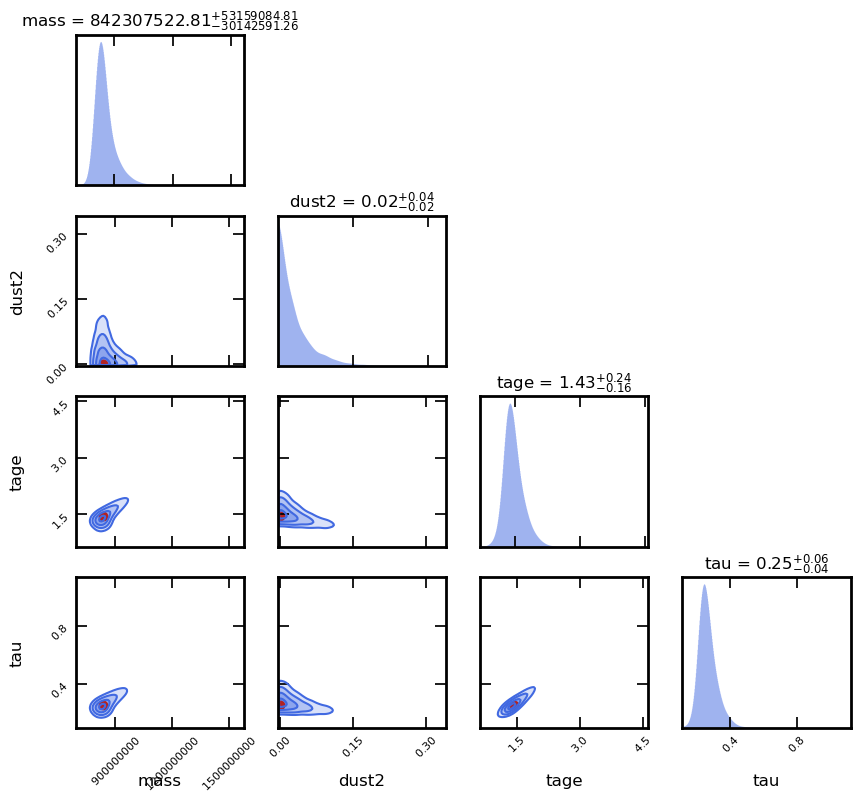

In [442]:
import matplotlib.pyplot as pl
from prospect.plotting import corner
nsamples, ndim = out["chain"].shape
cfig, axes = pl.subplots(ndim, ndim, figsize=(10,9))
axes = corner.allcorner(out["chain"].T, out["theta_labels"], axes, weights=out["weights"], color="royalblue", show_titles=True)

from prospect.plotting.utils import best_sample
pbest = best_sample(out)
corner.scatter(pbest[:, None], axes, color="firebrick", marker="o")
out["theta_labels"]

{'parameter': array([8.33311893e+08, 2.29719343e-04, 1.44562680e+00, 2.53357391e-01]), 'photometry': array([1.88659056e-09, 1.98355492e-09, 2.11759716e-09, 3.29074517e-09,
       3.23708664e-09, 9.29561828e-09, 9.29561828e-09, 9.29561828e-09,
       1.32247980e-08, 1.28704651e-08, 1.28704651e-08, 1.53302015e-08,
       1.44586122e-08, 1.44586122e-08, 1.65488727e-08, 9.25332970e-09,
       5.35147238e-09]), 'restframe_wavelengths': array([9.100e+01, 9.400e+01, 9.600e+01, ..., 9.817e+07, 9.908e+07,
       1.000e+08]), 'spectrum': array([3.47930499e-15, 2.89745005e-15, 3.78597554e-15, ...,
       4.51396948e-14, 4.39439823e-14, 4.15723812e-14]), 'mfrac': 0.6656502011211921}


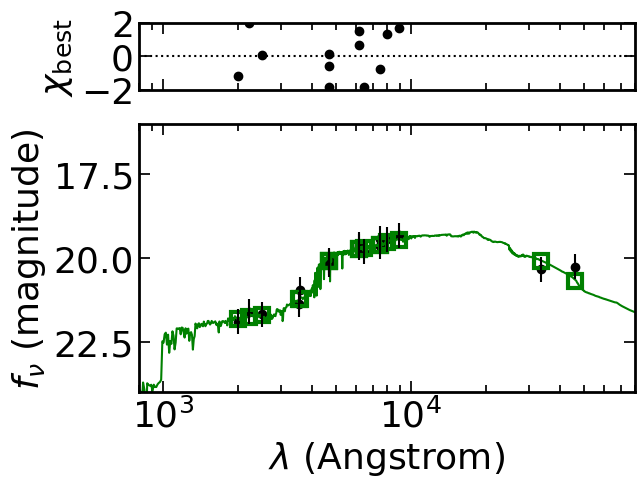

In [443]:
import matplotlib.pyplot as pl
sfig, saxes = pl.subplots(2, 1, gridspec_kw=dict(height_ratios=[1, 4]), sharex=True)
ax = saxes[1]
ax.ticklabel_format(axis='y', style='plain')
pwave = np.array([f.wave_effective for f in out_obs["filters"]])
# plot the data
ax.plot(pwave, np.log10(out_obs["maggies"])/-0.4, linestyle="", marker="o", color="k")
ax.errorbar(pwave,  np.log10(out_obs["maggies"])/-0.4, np.log(10)*np.divide(out_obs["maggies_unc"], out_obs["maggies"])/0.4, linestyle="", color="k", zorder=10)
ax.set_ylabel(r"$f_\nu$ (magnitude)")
ax.set_xlabel(r"$\lambda$ (Angstrom)")
ax.set_xlim(800, 8e4)
#ax.set_xlim(6500*(1+redshifts[obj_name]), 6800*(1+redshifts[obj_name]))
ax.set_ylim(24, 16)
ax.set_xscale('log')

# get the best-fit SED
bsed = out["bestfit"]
print(bsed)
ax.plot(bsed["restframe_wavelengths"]*(1+redshifts[obj_name]), np.log10(bsed["spectrum"])/-0.4, color="green", label="MAP sample")
ax.plot(pwave, np.log10(bsed["photometry"])/-0.4, linestyle="", marker="s", markersize=10, mec="green", mew=3, mfc="none")
#ax.plot(obs['wavelength'], np.log10(mspec_map)/-0.4, lw=3, color='tab:blue')
#ax.plot(obs["phot_wave"], np.log10(mphot_map)/-0.4, linestyle="", marker="s", markersize=10, mec="orange", mew=3, mfc="none")


ax = saxes[0]
chi = (out_obs["maggies"] - bsed["photometry"]) / out_obs["maggies_unc"]
ax.plot(pwave, chi, linestyle="", marker="o", color="k")
ax.axhline(0, color="k", linestyle=":")
ax.set_ylim(-2, 2)
ax.set_ylabel(r"$\chi_{\rm best}$")
plt.savefig('AT2024wpp_allphot.png', dpi=300)
pd.DataFrame(data={'rest_wave': bsed["restframe_wavelengths"]*(1+redshifts[obj_name]), 'flux': bsed["spectrum"]}).to_csv('data/AT2024wpp/2024wpp_z-0.4_noneb.csv')

    


[ 6.11313435e+10  8.42375553e-01  9.18295362e-01  1.41435854e-01
  3.53065524e-01 -3.80306786e+00]
[ 9.90879529e+09  6.20748017e-01  4.19902716e-01  1.01640491e-01
 -6.60658986e-01 -2.77325473e+00]
[ 3.37087565e+10  4.50892283e-01  1.68802924e+00  3.71254659e-01
  4.84268068e-01 -3.90867258e+00]
[ 8.63103877e+08  3.12879644e-04  5.49594096e-01  1.00681693e-01
  3.09559128e-01 -3.99427111e+00]
[ 1.04987541e+10  8.67401722e-01  5.79547725e-01  1.00678409e-01
  1.36287412e-01 -3.73328019e+00]
[ 6.77210222e+08  6.12655659e-01  3.61943615e-01  1.43282858e-01
 -3.49424198e-01 -2.71578672e+00]


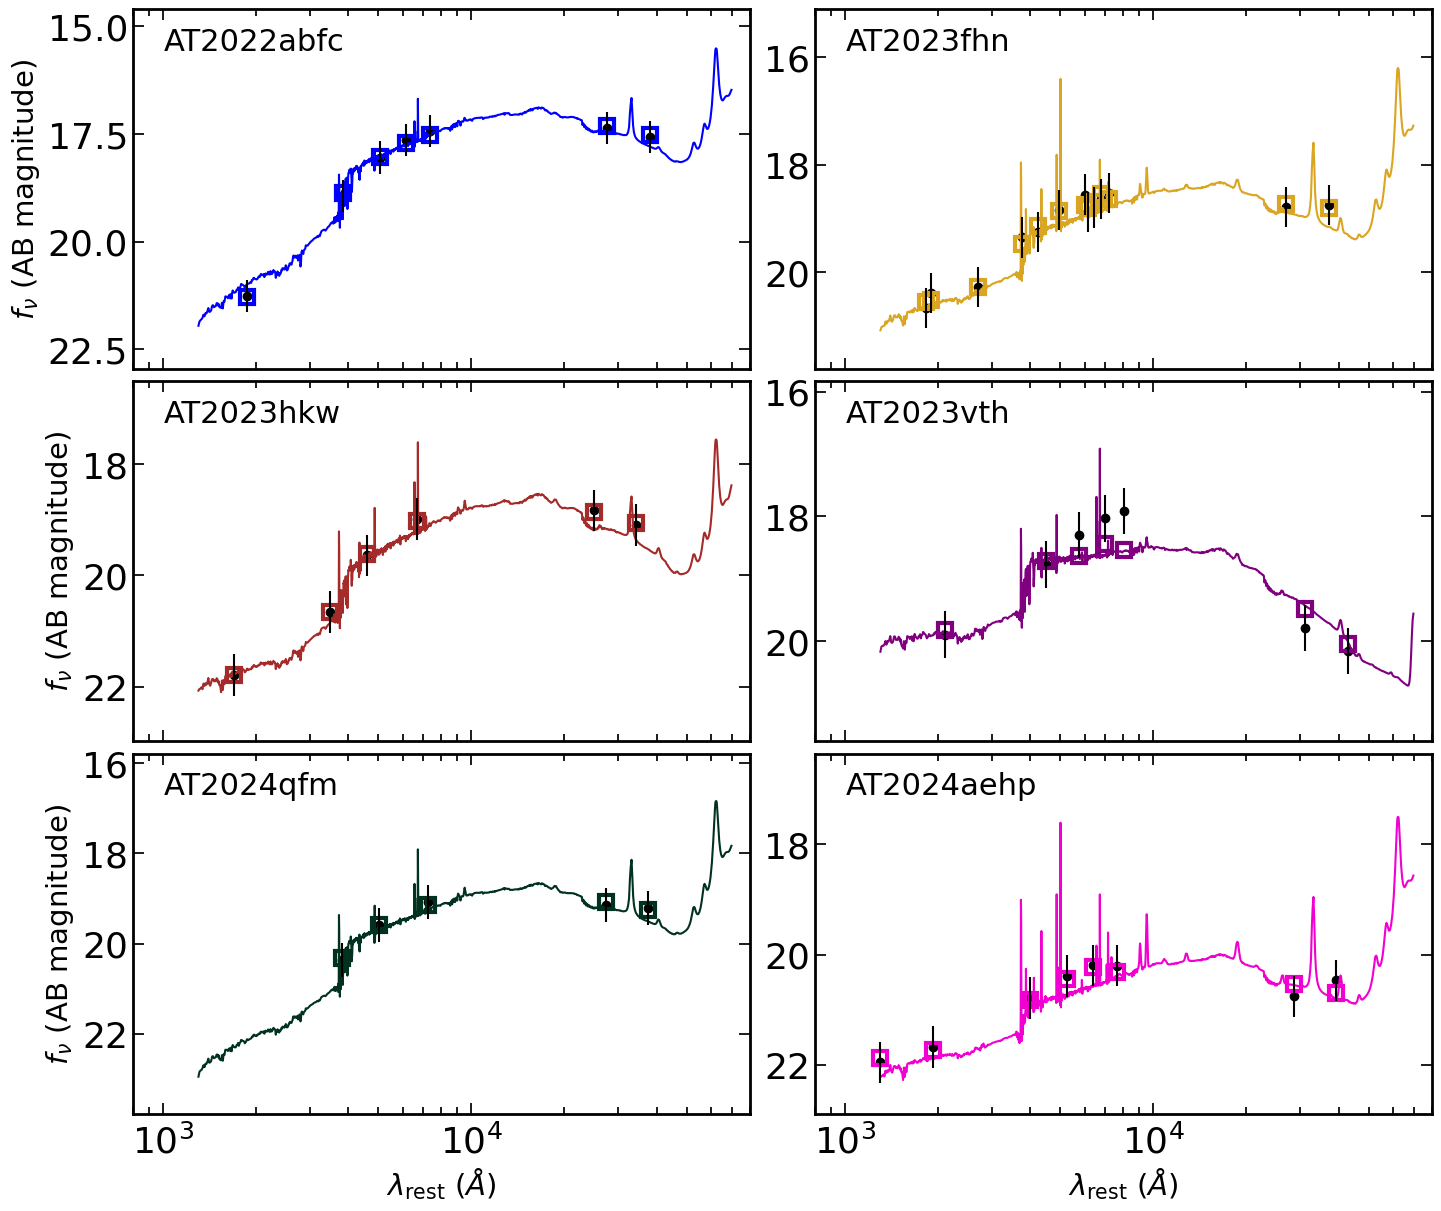

In [40]:
fig,axs=plt.subplots(3,2, figsize=(14.3,12), sharex=True, layout='constrained')
ax_list=axs.flatten()

objects=['AT2022abfc', 'AT2023fhn', 'AT2023hkw', 'AT2023vth', 'AT2024qfm', 'AT2024aehp']
for i, ob_name in enumerate(objects):
    hfile = "./data/{}/{}_fixedZLS.h5".format(ob_name,ob_name[2:])
    out, out_obs, out_model = reader.results_from(hfile)
    ax=ax_list[i]
    # Get maximum a posteriori parameters
    imax = np.argmax(out['lnprobability'])
    theta_max = out["chain"][imax, :]

    # Retrieve photometry and spectrum for maximum a posteriori model
    model_params["lumdist"] = {"N": 1, "isfree": False, "init": (Planck18.luminosity_distance(z=redshifts[ob_name])).to(u.Mpc).value, "units":"Mpc"}; model = PolySpecModel(model_params)
    spec, phot, x = model.predict(theta_max, obs=out_obs, sps=sps)
    pwave = np.array([f.wave_effective for f in out_obs["filters"]])
    # plot the data
    ax.plot(pwave/(1+redshifts[ob_name]), np.log10(out_obs["maggies"])/-0.4, linestyle="", marker="o", color="k")
    ax.errorbar(pwave/(1+redshifts[ob_name]),  np.log10(out_obs["maggies"])/-0.4, np.log(10)*np.divide(out_obs["maggies_unc"], out_obs["maggies"])/0.4, linestyle="", color="k", zorder=10)
    if (i==4) | (i==5): ax.set_xlabel(r"$\lambda_{\text{rest}}$ ($\AA$)", fontsize=21)
    if (i==0) | (i==2) | (i==4): ax.set_ylabel(r"$f_\nu$ (AB magnitude)", fontsize=21)

    # get the best-fit SED
    bsed = out["bestfit"]
    indices = np.nonzero((bsed["spectrum"]>0)&(bsed["restframe_wavelengths"]<70000)&(bsed["restframe_wavelengths"]>1300))[0]
    ax.plot(bsed["restframe_wavelengths"][indices], np.log10(spec[indices])/-0.4, color=vals.colors[ob_name], label="Prospector Fit")
    ax.plot(pwave/(1+redshifts[ob_name]), np.log10(bsed["photometry"])/-0.4, linestyle="", marker="s", markersize=10, mec=vals.colors[ob_name], mew=3, mfc="none")
    #ax.plot(out_obs["wavelength"], np.log10(out_obs['spectrum'])/-0.4, color="black", alpha=0.23, label='Observed Spectrum')

    #ax.set_xlim(0.5e3, 1.1e4)
    ax.set_xlim(800, 8e4)
    ax.set_xscale('log')
    ax.set_ylim(np.max(np.log10(bsed["spectrum"][indices])/-0.4)+0.8, np.min(np.log10(bsed["spectrum"][indices])/-0.4)-1)
    ax.tick_params(axis='x', which='major', pad=7)
    #ax.legend(prop={'size': 14})

    ax.text(0.05, 0.95, '{}'.format(ob_name), fontsize=22, va='top', ha='left', transform=ax.transAxes)
    plt.savefig('figures/fig10_specfit.pdf', dpi=450)


{'parameter': array([ 3.37087565e+10,  4.50892283e-01,  1.68802924e+00,  3.71254659e-01,
        4.84268068e-01, -3.90867258e+00]), 'photometry': array([5.47702446e-09, 1.41684906e-08, 2.44346312e-08, 1.91283603e-09,
       2.84283011e-08, 2.40207845e-08]), 'restframe_wavelengths': array([9.100e+01, 9.400e+01, 9.600e+01, ..., 9.817e+07, 9.908e+07,
       1.000e+08]), 'spectrum': array([ 2.10965768e-11, -2.42014733e-14, -4.01696849e-16, ...,
        7.04500543e-10,  7.04182506e-10,  6.82180015e-10]), 'mfrac': 0.6752320952998688}


/var/folders/kf/b04lmqv50dd7ydhwb_qbmtf80000gq/T/ipykernel_2105/1894516056.py:15: RuntimeWarning: invalid value encountered in log10
  ax.plot(bsed["restframe_wavelengths"]*(1+redshifts[obj_name]), np.log10(bsed["spectrum"])/-0.4, color=vals.colors[obj_name], label="Prospector Fit")
/var/folders/kf/b04lmqv50dd7ydhwb_qbmtf80000gq/T/ipykernel_2105/1894516056.py:17: RuntimeWarning: invalid value encountered in log10
  ax.plot(bsed["restframe_wavelengths"]*(1+redshifts[obj_name]), np.log10(bsed['spectrum'] )/-0.4, color="black", alpha=0.23, label='Observed Spectrum')


Text(0.5, 1.0, 'AT2023hkw Host Galaxy Fit')

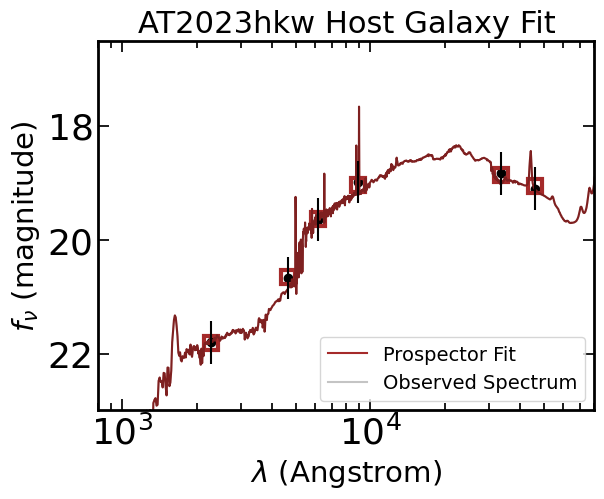

In [752]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)

pwave = np.array([f.wave_effective for f in out_obs["filters"]])
# plot the data
ax.plot(pwave/(1+redshifts[obj_name]), np.log10(out_obs["maggies"])/-0.4, linestyle="", marker="o", color="k")
ax.errorbar(pwave/(1+redshifts[obj_name]),  np.log10(out_obs["maggies"])/-0.4, np.log(10)*np.divide(out_obs["maggies_unc"], out_obs["maggies"])/0.4, linestyle="", color="k", zorder=10)
ax.set_ylabel(r"$f_\nu$ (magnitude)", fontsize=21)
ax.set_xlabel(r"$\lambda$ (Angstrom)", fontsize=21)

# get the best-fit SED
bsed = out["bestfit"]
indices = np.nonzero((bsed["spectrum"]>0)&(bsed["restframe_wavelengths"]<70000)&(bsed["restframe_wavelengths"]>1300))[0]
print(bsed)
ax.plot(bsed["restframe_wavelengths"], np.log10(bsed["spectrum"])/-0.4, color=vals.colors[obj_name], label="Prospector Fit")
ax.plot(pwave/(1+redshifts[obj_name]), np.log10(bsed["photometry"])/-0.4, linestyle="", marker="s", markersize=10, mec=vals.colors[obj_name], mew=3, mfc="none")
ax.plot(bsed["restframe_wavelengths"], np.log10(bsed['spectrum'] )/-0.4, color="black", alpha=0.23, label='Observed Spectrum')

ax.set_xlim(800, 8e4)
ax.set_xscale('log')
ax.set_ylim(np.max(np.log10(bsed["spectrum"][indices])/-0.4)+0.8, np.min(np.log10(bsed["spectrum"][indices])/-0.4)-1)
ax.legend(prop={'size': 14})

ax.set_title('{} Host Galaxy Fit'.format(obj_name), fontsize=22)
#plt.savefig('figures/{}_specfit.png'.format(obj_name))

In [753]:
print(out["chain"])

[[ 7.51120907e+12  5.59349520e+00  1.09460539e-02  1.83186480e+01
  -1.40773965e+00 -2.97784682e+00]
 [ 6.90141755e+12  3.32872772e+00  3.15775752e-02  2.93436011e+00
  -1.84061986e-01 -1.11338934e+00]
 [ 4.49232790e+12  7.42219240e+00  1.54965446e-03  5.31268822e-01
   4.91009321e-01 -1.34959872e+00]
 ...
 [ 4.94616977e+10  1.86742903e-01  2.99596903e+00  5.78256516e-01
  -9.70075247e-02 -3.70263328e+00]
 [ 4.91555817e+10  1.82465799e-01  2.93624402e+00  5.64156966e-01
  -5.30856943e-02 -3.97315148e+00]
 [ 4.77944510e+10  1.85637162e-01  2.84202950e+00  5.43338688e-01
  -1.90532802e-02 -3.72696996e+00]]


In [445]:
from prospect.plotting.sfh import parametric_sfr

def weighted_percentile(data, weights, perc):
    """
    perc : percentile in [0-1]!
    """
    ix = np.argsort(data)
    data = data[ix] # sort data
    weights = weights[ix] # sort weights
    cdf = (np.cumsum(weights) - 0.5 * weights) / np.sum(weights) # 'like' a CDF function
    return list(map(str, np.interp(perc, cdf, data)))

params=out["chain"].T

mass_alive=[]
for param in out["chain"]:
    mfrac=model.predict(param, obs=out_obs, sps=sps)[2]
    mass_alive.append(param[0]*mfrac)
['mass', 'logzsol', 'dust2', 'tage', 'tau', 'gas_logz', 'gas_logu']
fixed_Z=True
if fixed_Z:
    sfrs=parametric_sfr(times=0, tavg=0.001, tage=params[2], mass=params[0], logzsol=logz[obj_name],dust2=params[1],tau=params[3])
    print("Log Total Mass: ");print(','.join(weighted_percentile(np.log10(params[0]), out["weights"], [0.16, 0.5, 0.84])))
    print("Log Mass: ");print(','.join(weighted_percentile(np.log10(mass_alive), out["weights"], [0.16, 0.5, 0.84])))
    print("Log Z/Z_sun: ");print(logz[obj_name])
    print("Age: ");print(','.join(weighted_percentile(params[2], out["weights"], [0.16, 0.5, 0.84])))
    print("Dust Optical Depth: ");print(','.join(weighted_percentile(params[1], out["weights"], [0.16, 0.5, 0.84])))
    print("SFR: ");print(','.join(weighted_percentile(sfrs, out["weights"], [0.16, 0.5, 0.84])))
    print(len(params[0]))
else:
    sfrs=parametric_sfr(times=0, tavg=0.001, tage=params[3], mass=params[0], logzsol=params[1],dust2=params[2],tau=params[4])
    print("Log Total Mass: ");print(','.join(weighted_percentile(np.log10(mass_alive), out["weights"], [0.16, 0.5, 0.84])))
    print("Log Mass: ");print(','.join(weighted_percentile(np.log10(mass_alive), out["weights"], [0.16, 0.5, 0.84])))
    print("Log Z/Z_sun: ");print(','.join(weighted_percentile(params[1], out["weights"], [0.16, 0.5, 0.84])))
    print("Age: ");print(','.join(weighted_percentile(params[3], out["weights"], [0.16, 0.5, 0.84])))
    print("Dust Optical Depth: ");print(','.join(weighted_percentile(params[2], out["weights"], [0.16, 0.5, 0.84])))
    print("SFR: ");print(','.join(weighted_percentile(sfrs, out["weights"], [0.16, 0.5, 0.84])))
    print(len(params[0]))

#print("Log Total Mass: ");print(weighted_percentile(params[2], out["weights"], [0.16, 0.5, 0.84]))
#print("Log Mass: ");print(weighted_percentile(np.log10(mass_alive), out["weights"], [0.16, 0.5, 0.84]))
#print("Log Z/Z_sun: ");print(weighted_percentile(params[0], out["weights"], [0.16, 0.5, 0.84]))
#print("Age: ");print(weighted_percentile(params[3], out["weights"], [0.16, 0.5, 0.84]))
#print("SFR: ");print(weighted_percentile(sfrs, out["weights"], [0.16, 0.5, 0.84]))

Log Total Mass: 
8.909643129885762,8.925468201890169,8.952044110252647
Log Mass: 
8.735848376910427,8.750259306609818,8.771730992849628
Log Z/Z_sun: 
-0.4
Age: 
1.2705646679723044,1.4271248937818264,1.6670279017821792
Dust Optical Depth: 
0.005582106383703201,0.022649081809045315,0.06310043800042238
SFR: 
0.06300917517447953,0.06985733173624216,0.07756963449696677
13083


/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/io/write_results.py:60: RuntimeWarning: Could not store paramfile text
  warnings.warn("Could not store paramfile text", RuntimeWarning)
/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/io/write_results.py:301: RuntimeWarning: Could not JSON serialize model_params, pickled instead
  warnings.warn("Could not JSON serialize {}, pickled instead".format(k),
/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/io/write_results.py:49: RuntimeWarning: Could not obtain prospector version info
  warnings.warn("Could not obtain prospector version info", RuntimeWarning)


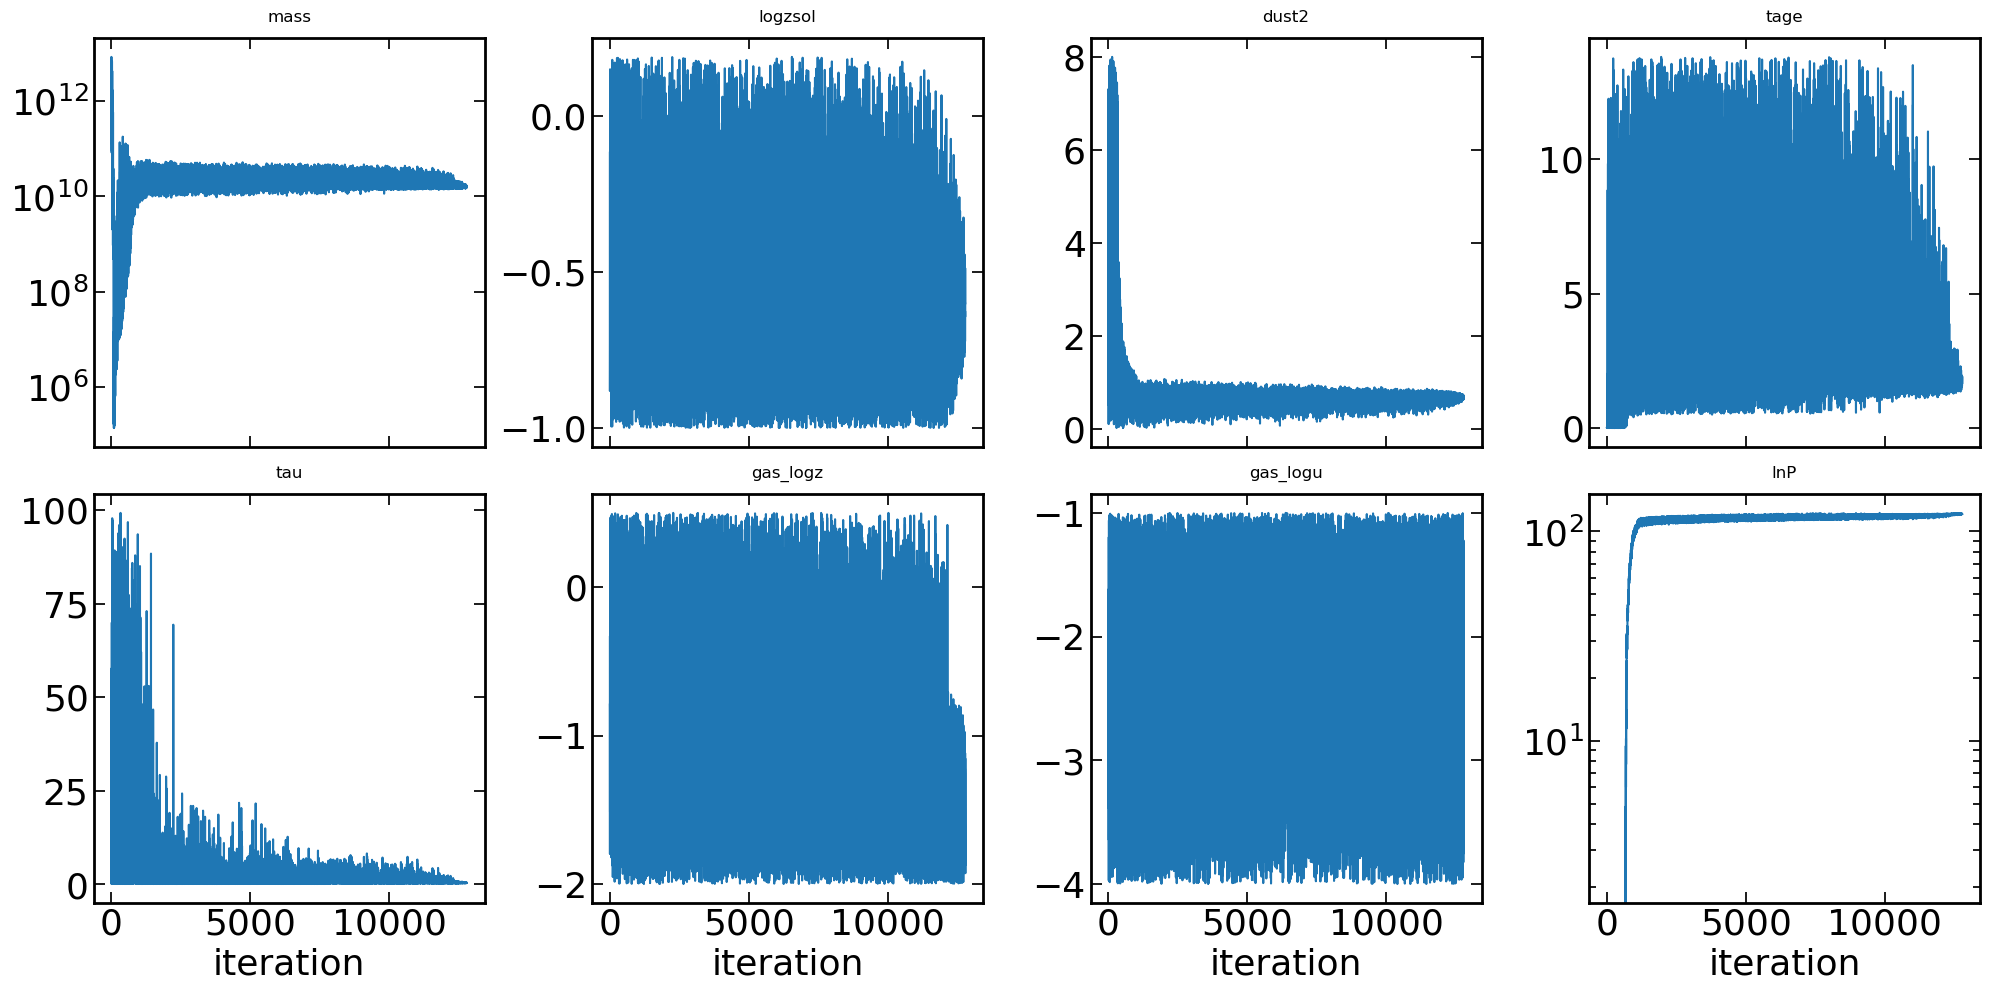

In [82]:
hfile                           = "{name}_prospector_{sampler}_phot.h5".format(name=obj_name, sampler=results_type)
writer.write_hdf5(hfile, run_params, model, obs,
                output["sampling"][0], output["optimization"][0],
                 sps=sps,
                 tsample=output["sampling"][1],
                 toptimize=output["optimization"][1])

result, obs, _                  = reader.results_from(hfile, dangerous=False)

tracefig = traceplot(result, figsize=(20,10))
#tracefig.savefig(hfile.replace('.h5', '_tracefig.pdf'))

In [120]:
fit_quality                     = compute_fitquality(result, obs, model, sps, TYPE=results_type)
fit_quality

{'CHI2': 2.085, 'NOF': 2}

In [121]:
result_copy                     = modify_chain(result, results_type, obs, model, sps)

/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/models/sedmodel.py:191: RuntimeWarning: invalid value encountered in divide
  self._sed = calibrated_spec / self._speccal
/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/models/sedmodel.py:191: RuntimeWarning: divide by zero encountered in divide
  self._sed = calibrated_spec / self._speccal
/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/models/sedmodel.py:509: RuntimeWarning: invalid value encountered in divide
  self._eline_lum[idx] = alpha_bar / linecal
/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/models/sedmodel.py:510: RuntimeWarning: invalid value encountered in divide
  self._eline_lum_var[idx] = np.diag(sigma_alpha_bar) / linecal**2
/opt/anaconda3/envs/prospector/lib/python3.12/site-packages/prospect/models/sedmodel.py:509: RuntimeWarning: divide by zero encountered in divide
  self._eline_lum[idx] = alpha_bar / linecal
/Users/jasonsevilla/Docu

In [63]:
brightness                      = subcorner(result_copy, obj_name,
                                                SHOWPARS=['MAGOBS_' + f.replace('_resampled', '') for f in obs['filternames']]
                                                        +['MAGABS_' + f.replace('_resampled', '') for f in obs['filternames']],
                                                SHOWPLOT=False, MAKEPLOT=False)

MAGOBS_sdss_g0 21.02828842901212 21.078278428541537 21.12960290565369
MAGOBS_sdss_r0 19.713750417009702 19.76149194809971 19.810888901285892
MAGOBS_sdss_i0 19.30079769588153 19.34822228822477 19.398409329440184
MAGOBS_sdss_z0 19.048322606870535 19.096905836046876 19.147714314431507
MAGABS_sdss_g0 -20.61545996920667 -20.565986958687887 -20.513166338349247
MAGABS_sdss_r0 -21.143532731758146 -21.090290846472517 -21.030976841220717
MAGABS_sdss_i0 -21.42139142884445 -21.366101317882748 -21.305218959395223
MAGABS_sdss_z0 -21.559719189819187 -21.508119282532697 -21.454880971501535


In [64]:
output_table                    = table.hstack([physical_props, brightness])

output_table['CHI2_BEST']       = fit_quality['CHI2']
output_table['NOF_BEST']        = int(fit_quality['NOF'])
output_table['NOF_BEST'].format = 'g'
output_table['OBJECT']          = obj_name
try:
    del output_table['ID_1']
except:
    pass

In [65]:
for p in ['INF', 'MED', 'SUP']:
        #print(output_table['DUST2_' + p][0])
        output_table['EBVSTAR_' + p]          = calzetti_ebv_star(output_table['DUST2_' + p])
        output_table['EBVSTAR_' + p].format   = '.3f'
print(np.array(obs['filternames'])=='sdss_r0')
mag[np.array(obs['filternames'])=='sdss_r0'][0]

[False  True False False]


19.66311318142389

In [66]:
filters                         = ['GALEX_FUV', 'GALEX_NUV',
                                        'UVOT_UVW2', 'UVOT_UVM2', 'UVOT_UVW1', 'UVOT_U', 'UVOT_B', 'UVOT_V', 
                                        'sdss_u0', 'sdss_g0', 'panstarrs_r', 'sdss_i0', 'sdss_z0',
                                        'PANSTARRS_G', 'PANSTARRS_R', 'PANSTARRS_I', 'PANSTARRS_Z', 'PANSTARRS_Y',
                                        'JOHNSON_U', 'JOHNSON_B', 'BESSELL_V', 'COUSINS_R', 'BESSELL_I',
                                        '2MASS_J', '2MASS_H', '2MASS_KS',
                                        'F225W', 'F390W', 'F606W',
                                        'F105W', 'F110W', 'F125W', 'F140W', 'F160W',
                                        'IRAC_I1', 'IRAC_I2', 'IRAC_I3', 'IRAC_I4',
                                        'WISE_W1', 'WISE_W2']

output_final                    = table.Table()
output_final['ID']              = [1000]
output_final['OBJECT']          = obj_name
output_final['REDSHIFT']        = redshifts[obj_name]
output_final['CHI2_BEST']       = output_table['CHI2_BEST']
output_final['NOF_BEST']        = output_table['NOF_BEST']
output_final['EXTMODEL']        = 'Calzetti'
output_final['ADD_NEB']         = True
output_final['ADD_DUSTE']       = False

for f in filters:
    output_final['MAGOBS_' + f]                 = mag[np.array(obs['filternames'])==f][0]         if f in obs['filternames'] else -99.
    output_final['MAGOBS_' + f + '_ERR']        = mag[np.array(obs['filternames'])==f][0]  if f in obs['filternames'] else -99.
    output_final['MAGOBS_' + f].format          = '.3f'
    output_final['MAGOBS_' + f + '_ERR'].format = '.3f'
    
for f in filters:
    for suffix in ['_INF', '_MED', '_SUP']:
        output_final['MAGMOD_' + f + suffix]        = output_table['MAGOBS_' + f + suffix] if 'MAGOBS_' + f + suffix in output_table.keys() else -99.
        output_final['MAGMOD_' + f + suffix].format = '.3f'

for f in filters:
    for suffix in ['_INF', '_MED', '_SUP']:
        output_final['MAGABS_' + f + suffix]        = output_table['MAGABS_' + f + suffix] if 'MAGABS_' + f + suffix in output_table.keys() else -99.
        output_final['MAGABS_' + f + suffix].format = '.3f'

for key in ['MASS', 'SFR', 'SSFR', 'TAGE', 'TAU', 'ZSOL', 'DUST2', 'EBVSTAR']:
    for suffix in ['_INF', '_MED', '_SUP']:
        output_final[key + suffix]                  = output_table[key + suffix] if key + suffix in output_table.keys() else -99.
        output_final[key + suffix].format           = '.3f'

del output_final['ID']
del output_table


#ascii.write(output_final, './' + '{}_output.ascii'.format(obs_cat['OBJECT'][0]), overwrite=True)

In [67]:
# write_posterior_dynesty(result_copy, hfile.replace('.h5', '_posterior_{}.fits'.format(results_type)))

In [69]:
fname_spec = 'lris2022tsd_steve.spec'
data_spec  = ascii.read(fname_spec, names=('wave_obs', 'flambda', 'flambda_err'))

obs2 = build_obs(obs_cat, data_spec, SIGMA=sigma, SHOW_ALL=True)
#obs3 = build_obs(obs_cat, SHOW_ALL=True)

FileNotFoundError: [Errno 2] No such file or directory: 'lris2022tsd_steve.spec'

In [70]:
sps2 = build_sps(obs=obs, object_redshift=run_params['zred'], **run_params)
sps2

In [71]:
output_final

OBJECT,REDSHIFT,CHI2_BEST,NOF_BEST,EXTMODEL,ADD_NEB,ADD_DUSTE,MAGOBS_GALEX_FUV,MAGOBS_GALEX_FUV_ERR,MAGOBS_GALEX_NUV,MAGOBS_GALEX_NUV_ERR,MAGOBS_UVOT_UVW2,MAGOBS_UVOT_UVW2_ERR,MAGOBS_UVOT_UVM2,MAGOBS_UVOT_UVM2_ERR,MAGOBS_UVOT_UVW1,MAGOBS_UVOT_UVW1_ERR,MAGOBS_UVOT_U,MAGOBS_UVOT_U_ERR,MAGOBS_UVOT_B,MAGOBS_UVOT_B_ERR,MAGOBS_UVOT_V,MAGOBS_UVOT_V_ERR,MAGOBS_sdss_u0,MAGOBS_sdss_u0_ERR,MAGOBS_sdss_g0,MAGOBS_sdss_g0_ERR,MAGOBS_sdss_r0,MAGOBS_sdss_r0_ERR,MAGOBS_sdss_i0,MAGOBS_sdss_i0_ERR,MAGOBS_sdss_z0,MAGOBS_sdss_z0_ERR,MAGOBS_PANSTARRS_G,MAGOBS_PANSTARRS_G_ERR,MAGOBS_PANSTARRS_R,MAGOBS_PANSTARRS_R_ERR,MAGOBS_PANSTARRS_I,MAGOBS_PANSTARRS_I_ERR,MAGOBS_PANSTARRS_Z,MAGOBS_PANSTARRS_Z_ERR,MAGOBS_PANSTARRS_Y,MAGOBS_PANSTARRS_Y_ERR,MAGOBS_JOHNSON_U,MAGOBS_JOHNSON_U_ERR,MAGOBS_JOHNSON_B,MAGOBS_JOHNSON_B_ERR,MAGOBS_BESSELL_V,MAGOBS_BESSELL_V_ERR,MAGOBS_COUSINS_R,MAGOBS_COUSINS_R_ERR,MAGOBS_BESSELL_I,MAGOBS_BESSELL_I_ERR,MAGOBS_2MASS_J,MAGOBS_2MASS_J_ERR,MAGOBS_2MASS_H,MAGOBS_2MASS_H_ERR,MAGOBS_2MASS_KS,MAGOBS_2MASS_KS_ERR,MAGOBS_F225W,MAGOBS_F225W_ERR,MAGOBS_F390W,MAGOBS_F390W_ERR,MAGOBS_F606W,MAGOBS_F606W_ERR,MAGOBS_F105W,MAGOBS_F105W_ERR,MAGOBS_F110W,MAGOBS_F110W_ERR,MAGOBS_F125W,MAGOBS_F125W_ERR,MAGOBS_F140W,MAGOBS_F140W_ERR,MAGOBS_F160W,MAGOBS_F160W_ERR,MAGOBS_IRAC_I1,MAGOBS_IRAC_I1_ERR,MAGOBS_IRAC_I2,MAGOBS_IRAC_I2_ERR,MAGOBS_IRAC_I3,MAGOBS_IRAC_I3_ERR,MAGOBS_IRAC_I4,MAGOBS_IRAC_I4_ERR,MAGOBS_WISE_W1,MAGOBS_WISE_W1_ERR,MAGOBS_WISE_W2,MAGOBS_WISE_W2_ERR,MAGMOD_GALEX_FUV_INF,MAGMOD_GALEX_FUV_MED,MAGMOD_GALEX_FUV_SUP,MAGMOD_GALEX_NUV_INF,MAGMOD_GALEX_NUV_MED,MAGMOD_GALEX_NUV_SUP,MAGMOD_UVOT_UVW2_INF,MAGMOD_UVOT_UVW2_MED,MAGMOD_UVOT_UVW2_SUP,MAGMOD_UVOT_UVM2_INF,MAGMOD_UVOT_UVM2_MED,MAGMOD_UVOT_UVM2_SUP,MAGMOD_UVOT_UVW1_INF,MAGMOD_UVOT_UVW1_MED,MAGMOD_UVOT_UVW1_SUP,MAGMOD_UVOT_U_INF,MAGMOD_UVOT_U_MED,MAGMOD_UVOT_U_SUP,MAGMOD_UVOT_B_INF,MAGMOD_UVOT_B_MED,MAGMOD_UVOT_B_SUP,MAGMOD_UVOT_V_INF,MAGMOD_UVOT_V_MED,MAGMOD_UVOT_V_SUP,MAGMOD_sdss_u0_INF,MAGMOD_sdss_u0_MED,MAGMOD_sdss_u0_SUP,MAGMOD_sdss_g0_INF,MAGMOD_sdss_g0_MED,MAGMOD_sdss_g0_SUP,MAGMOD_sdss_r0_INF,MAGMOD_sdss_r0_MED,MAGMOD_sdss_r0_SUP,MAGMOD_sdss_i0_INF,MAGMOD_sdss_i0_MED,MAGMOD_sdss_i0_SUP,MAGMOD_sdss_z0_INF,MAGMOD_sdss_z0_MED,MAGMOD_sdss_z0_SUP,MAGMOD_PANSTARRS_G_INF,MAGMOD_PANSTARRS_G_MED,MAGMOD_PANSTARRS_G_SUP,MAGMOD_PANSTARRS_R_INF,MAGMOD_PANSTARRS_R_MED,MAGMOD_PANSTARRS_R_SUP,MAGMOD_PANSTARRS_I_INF,MAGMOD_PANSTARRS_I_MED,MAGMOD_PANSTARRS_I_SUP,MAGMOD_PANSTARRS_Z_INF,MAGMOD_PANSTARRS_Z_MED,MAGMOD_PANSTARRS_Z_SUP,MAGMOD_PANSTARRS_Y_INF,MAGMOD_PANSTARRS_Y_MED,MAGMOD_PANSTARRS_Y_SUP,MAGMOD_JOHNSON_U_INF,MAGMOD_JOHNSON_U_MED,MAGMOD_JOHNSON_U_SUP,MAGMOD_JOHNSON_B_INF,MAGMOD_JOHNSON_B_MED,MAGMOD_JOHNSON_B_SUP,MAGMOD_BESSELL_V_INF,MAGMOD_BESSELL_V_MED,MAGMOD_BESSELL_V_SUP,MAGMOD_COUSINS_R_INF,MAGMOD_COUSINS_R_MED,MAGMOD_COUSINS_R_SUP,MAGMOD_BESSELL_I_INF,MAGMOD_BESSELL_I_MED,MAGMOD_BESSELL_I_SUP,MAGMOD_2MASS_J_INF,MAGMOD_2MASS_J_MED,MAGMOD_2MASS_J_SUP,MAGMOD_2MASS_H_INF,MAGMOD_2MASS_H_MED,MAGMOD_2MASS_H_SUP,MAGMOD_2MASS_KS_INF,MAGMOD_2MASS_KS_MED,MAGMOD_2MASS_KS_SUP,MAGMOD_F225W_INF,MAGMOD_F225W_MED,MAGMOD_F225W_SUP,MAGMOD_F390W_INF,MAGMOD_F390W_MED,MAGMOD_F390W_SUP,MAGMOD_F606W_INF,MAGMOD_F606W_MED,MAGMOD_F606W_SUP,MAGMOD_F105W_INF,MAGMOD_F105W_MED,MAGMOD_F105W_SUP,MAGMOD_F110W_INF,MAGMOD_F110W_MED,MAGMOD_F110W_SUP,MAGMOD_F125W_INF,MAGMOD_F125W_MED,MAGMOD_F125W_SUP,MAGMOD_F140W_INF,MAGMOD_F140W_MED,MAGMOD_F140W_SUP,MAGMOD_F160W_INF,MAGMOD_F160W_MED,MAGMOD_F160W_SUP,MAGMOD_IRAC_I1_INF,MAGMOD_IRAC_I1_MED,MAGMOD_IRAC_I1_SUP,MAGMOD_IRAC_I2_INF,MAGMOD_IRAC_I2_MED,MAGMOD_IRAC_I2_SUP,MAGMOD_IRAC_I3_INF,MAGMOD_IRAC_I3_MED,MAGMOD_IRAC_I3_SUP,MAGMOD_IRAC_I4_INF,MAGMOD_IRAC_I4_MED,MAGMOD_IRAC_I4_SUP,MAGMOD_WISE_W1_INF,MAGMOD_WISE_W1_MED,MAGMOD_WISE_W1_SUP,MAGMOD_WISE_W2_INF,MAGMOD_WISE_W2_MED,MAGMOD_WISE_W2_SUP,MAGABS_GALEX_FUV_INF,MAGABS_GALEX_FUV_MED,MAGABS_GALEX_FUV_SUP,MAGABS_GALEX_NUV_INF,MAGABS_GALEX_NUV_MED,MAGABS_GALEX_NUV_SUP,MAGABS_UVOT_UVW2_INF,MAGABS_UVOT_UVW2_MED,MAGABS_UVOT_UVW2_SUP

In [72]:
fname_spec = 'lris2022tsd_steve.spec'
data_spec  = ascii.read(fname_spec, names=('wave_obs', 'flambda', 'flambda_err'))

obs2 = build_obs(obs_cat, data_spec, SIGMA=sigma, SHOW_ALL=True)

FileNotFoundError: [Errno 2] No such file or directory: 'lris2022tsd_steve.spec'

/Users/jasonsevilla/Documents/Cornell/Transients/2024_Summer_Optical/routines_prospector.py:894: RuntimeWarning: invalid value encountered in log10
  ax.plot(OBS2['wavelength'], -2.5*np.log10(OBS2['spectrum']), '-', lw=3, color='black', alpha=0.2)


<class 'sedpy.observate.Filter'>(sdss_g0)
<class 'sedpy.observate.Filter'>(sdss_r0)
<class 'sedpy.observate.Filter'>(sdss_i0)
<class 'sedpy.observate.Filter'>(sdss_z0)


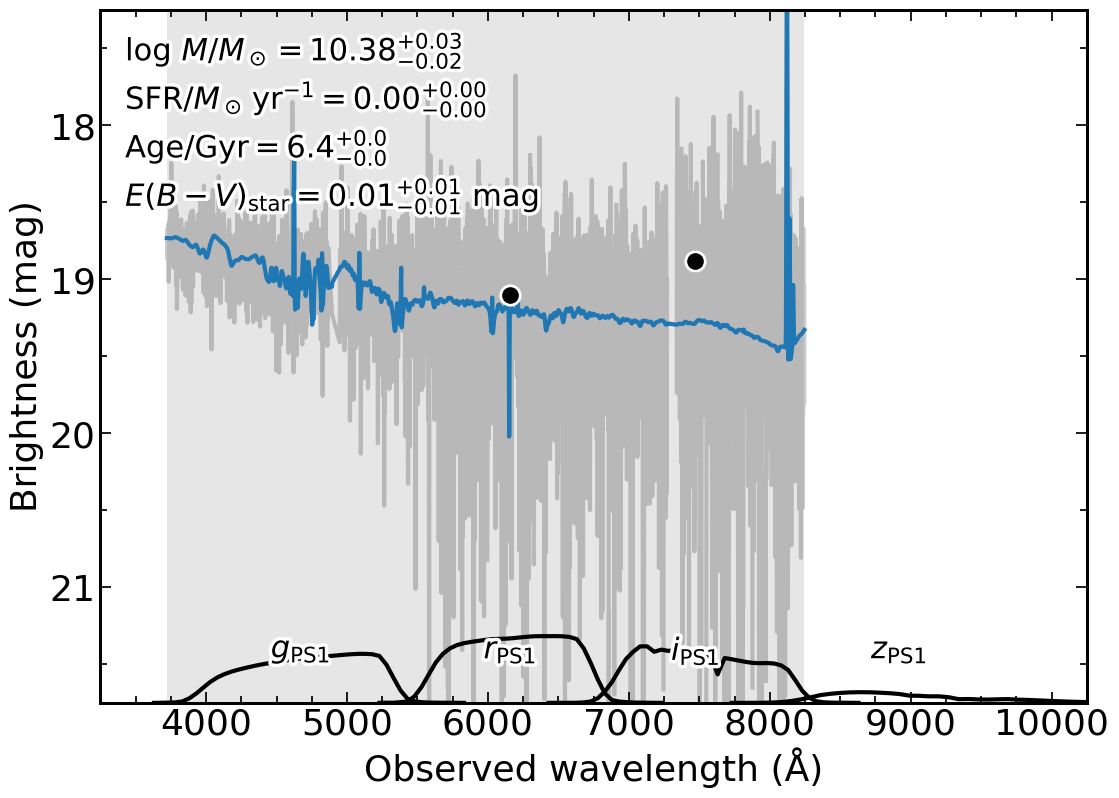

In [282]:
sed_plot(result, obs, obs, model, sps, output_final, SHOWPLOT=False, OUTDIR='./', TYPE=results_type)

In [54]:
obs2

{'filters': [<class 'sedpy.observate.Filter'>(sdss_G0),
  <class 'sedpy.observate.Filter'>(sdss_R0),
  <class 'sedpy.observate.Filter'>(sdss_I0),
  <class 'sedpy.observate.Filter'>(sdss_Z0),
  <class 'sedpy.observate.Filter'>(BESSELL_V)],
 'maggies': array([6.61302249e-09, 9.81747943e-09, 9.16220490e-09, 1.24165231e-08,
        1.00000000e-09]),
 'maggies_unc': array([6.93154270e-10, 6.46273740e-10, 7.19812939e-10, 1.22971247e-09,
        0.00000000e+00]),
 'phot_mask': array([ True,  True,  True,  True, False]),
 'phot_wave': array([4669.59393552, 6155.68605117, 7471.57138923, 8917.3987151 ,
        5455.61856726]),
 'wavelength': <Column name='wave_obs' dtype='float64' length=4545>
 3109.5527
 3111.5088
 3113.4653
 3115.4226
 3117.3806
 3119.3394
 3121.2986
 3123.2585
 3125.2192
 3127.1804
 3129.1423
  3131.105
       ...
 9634.2275
 9635.4082
 9636.5889
 9637.7705
 9638.9512
 9640.1318
 9641.3125
 9642.4932
 9643.6748
 9644.8555
 9646.0361,
 'spectrum': <Column name='flambda' dtype=

In [55]:
obs2=copy.deepcopy(obs)

In [56]:
if ('spectrum' in obs.keys()):
        obs2['wavelength'] = np.logspace(np.log10(1000.), np.log10(3e7), 15000)
        obs2['mask'] = np.ones_like(obs2['wavelength'], dtype=bool)
        obs2['unc'] = np.ones_like(obs2['wavelength'])
        obs2['spectrum'] = np.ones_like(obs2['wavelength'])
        do_not_overplot_mask = ( 
            (obs2['wavelength']>obs['wavelength'][0])
            & (obs2['wavelength']<obs['wavelength'][-1]))

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
/var/folders/kf/b04lmqv50dd7ydhwb_qbmtf80000gq/T/ipykernel_2514/3614208531.py:9: SyntaxWarning: invalid escape sequence '\m'
  """
/var/folders/kf/b04lmqv50dd7ydhwb_qbmtf80000gq/T/ipykernel_2514/3614208531.py:30: SyntaxWarning: invalid escape sequence '\m'
  label='$\mathrm{Delayed}$-$\\tau \; \mathrm{model\;SED}$')
/var/folders/kf/b04lmqv50dd7ydhwb_qbmtf80000gq/T/ipykernel_2514/3614208531.py:9: SyntaxWarning: invalid escape sequence '\m'
  """
/var/folders/kf/b04lmqv50dd7ydhwb_qbmtf80000gq/T/ipykernel_2514/3614208531.py:30: SyntaxWarning: invalid escape sequence '\m'
  label='$\mathrm{Delayed}$-$\\tau \; \mathrm{model\;SED}$')


NameError: name 'mag_mask_det' is not defined

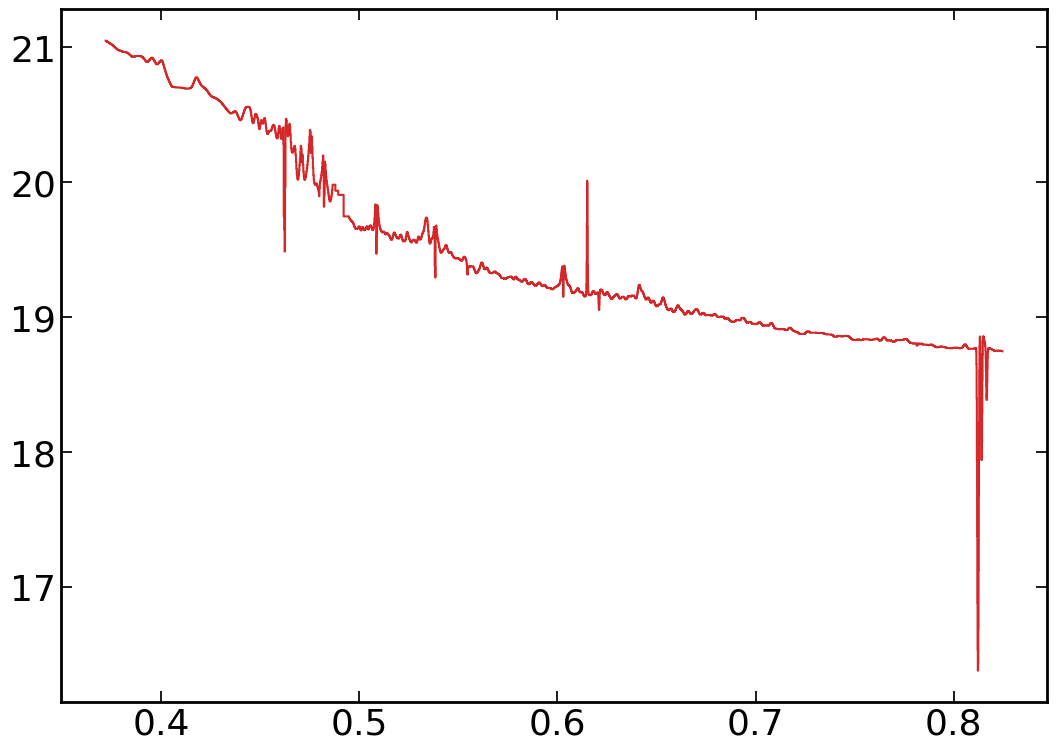

In [283]:
plt.figure(figsize=(9*np.sqrt(2), 9))
ax=plt.subplot(111)

if True:#('spectrum' in obs.keys()):

        imax = np.argmax(result['lnprobability'])
        theta_max = result["chain"][imax, :]

        """
        #pbest = result['bestfit']['parameter']
        _, phot2, _ = model.predict(pbest, obs2, sps=sps)
        model_sed = model._sed
        model_sed[do_not_overplot_mask] = np.nan
        ax.step(obs2['wavelength']/1e4, -2.5*np.log10(model_sed), color='tab:blue',
                 where='mid',
                 label='$\mathrm{Delayed}$-$\\tau \; \mathrm{model\;SED}$')
        """

        #mspec_map, mphot_map, _ = model.mean_model(theta_max, obs, spec=sps)
        #wspec = sps.wavelengths * (1 + redshifts[obj_name])

        #ax.plot(wspec, mspec_map)

        
        model.predict(theta_max, obs, sps=sps)
        model_sed = model._sed
        #model_sed[do_not_overplot_mask] = np.nan
        ax.step(obs['wavelength']/1e4, -2.5*np.log10(model_sed), color='tab:red',
                 where='mid',
                 label='$\mathrm{Delayed}$-$\\tau \; \mathrm{model\;SED}$')

        #ax.step(wspec/1e4, -2.5*np.log10(model_sed), color='tab:red',
        #         where='mid',
        #         label='$\mathrm{Delayed}$-$\\tau \; \mathrm{model\;SED}$')

        #ax.plot(obs['wavelength']/1e4, -2.5*np.log10(obs['spectrum']), '-', lw=3, color='black', alpha=0.2)
        
print(len(np.intersect1d(mag_mask_det, mag_mask)))
wobs        = np.array(obs2['phot_wave'])
mag_obs     = -2.5*np.log10(obs['maggies'])
mag_err     = mag_obs + 2.5*np.log10(obs['maggies']+obs['maggies_unc'])
mag_err     += -2.5*np.log10(obs['maggies'] - obs['maggies_unc']) - mag_obs 
mag_err     /= 2.
mag_mask    = [i for i in range(len(obs['phot_mask'])) if obs['phot_mask'][i] == True]
mag_mask_det= np.where(obs['maggies_unc'] / obs['maggies'] < 1e3)[0]
mag_mask_ul = np.where(obs['maggies_unc'] / obs['maggies'] == 1000.)[0]

ax.errorbar(wobs[np.intersect1d(mag_mask_det, mag_mask)]/1e4, mag_obs[np.intersect1d(mag_mask_det, mag_mask)], yerr=mag_err[np.intersect1d(mag_mask_det, mag_mask)], 
         lw=0, marker='o', ms=14, elinewidth=2, capsize=0, color='black', zorder=2, mew=2, mec='white')
       
ax.errorbar(wobs[np.intersect1d(mag_mask_ul, mag_mask)]/1e4, -2.5*np.log10(3 * obs['maggies_unc'][np.intersect1d(mag_mask_ul, mag_mask)]),
         lw=0, marker='v', ms=9, elinewidth=2, capsize=0, color='k', zorder=2)

ax.set_xlim(0.35, 1.05)
ax.set_ylim(21.5, 16.5)


In [ ]:
-2.5*np.log10(obs['spectrum'])

In [ ]:
obs.keys()

In [ ]:
obs['wavelength']

In [ ]:
theta_max

In [74]:
TemplateLibrary.show_contents()

'type_defaults':
  Explicitly sets dust amd IMF types.
'ssp':
  Basic set of (free) parameters for a delta function SFH
'parametric_sfh':
  Basic set of (free) parameters for a delay-tau SFH.
'dust_emission':
  The set of (fixed) dust emission parameters.
'nebular':
  The set of nebular emission parameters, with gas_logz tied to stellar logzsol.
'nebular_marginalization':
  Marginalize over emission amplitudes line contained inthe observed spectrum
'fit_eline_redshift':
  Fit for the redshift of the emission lines separatelyfrom the stellar redshift
'agn_eline':
  Add AGN emission lines
'outlier_model':
  The set of outlier (mixture) models for spectroscopy and photometry
'agn':
  The set of (fixed) AGN dusty torus emission parameters.
'igm':
  The set of (fixed) IGM absorption parameters.
'spectral_smoothing':
  Set of parameters for spectal smoothing.
'optimize_speccal':
  Set of parameters (most of which are fixed) for optimizing a polynomial calibration vector.
'fit_speccal':
  Set

In [70]:
obs['phot_wave'][np.array([0,1])]

TypeError: only integer scalar arrays can be converted to a scalar index

In [81]:
a=np.array([0,1,2])
a=np.array(obs['phot_wave'])
a[np.array([2, 2, 1, 0])]

array([7471.57138923, 7471.57138923, 6155.68605117, 4669.59393552])

In [26]:
# AT2022abfc LS
# Fixed Z
Log Total Mass: 
10.764655862531049,10.795012556560364,10.822748026971544
Log Mass: 
10.60882122891655,10.63609498551945,10.660529878042679
Log Z/Z_sun: 
0.05491899643000091
Age: 
0.8268713172969927,0.9665801844928825,1.1174603531454455
Dust Optical Depth: 
0.7924847316376448,0.8316037980059356,0.8700397067755563
SFR: 
3.68172858175936,4.3007101302536155,4.921330455197504

# Free Z
Log Total Mass: 
[10.98929501 11.0624705  11.32048617]
Log Mass: 
[10.81520352 10.8704081  11.09801531]
Log Z/Z_sun: 
[-1.18772808 -0.88338335 -0.35965594]
Age: 
[1.13623054 1.75863649 4.77117211]
SFR: 
[3.84835217 5.14926491 6.24718366]


# AT2023hkw LS
# Fized Z
Log Total Mass: 
10.557749354879311,10.661027615967404,10.776302501570063
Log Mass: 
10.382449688059301,10.47260413743541,10.575700614602598
Log Z/Z_sun: 
0.03484174200000151
Age: 
1.8520330784450159,2.652509139453208,3.8894702829423076
Dust Optical Depth: 
0.08716333662757288,0.22496164825145962,0.39441472925126086
SFR: 
2.002167599575805,2.7521105276805016,4.1073354920445935
# Free Z
Log Total Mass: 
[10.36302267 10.53326871 10.66824392]
Log Mass: 
[10.16660095 10.31573353 10.43722641]
Log Z/Z_sun: 
[-1.12563035 -0.74365453 -0.38518058]
Age: 
[ 2.94541091  6.42621426 11.03386843]
SFR: 
[1.77614177 2.54433636 3.41106079]

# AT2023fhn LS
# Fixed Z
Log Total Mass: 
10.005189386906897,10.066857842946915,10.134252580214296
Log Mass: 
9.868910873646037,9.923221874058727,9.981261150318819
Log Z/Z_sun: 
-0.2702932382299956
Age: 
0.4864075627099386,0.6866592504068885,1.21236980662559
Dust Optical Depth: 
0.537141142048246,0.5910751622717094,0.6391368395128293
SFR: 
6.57488219426011,7.7378497620322735,9.118187525828919

# Free Z
Log Total Mass: 
[10.10231136 10.19014208 10.33372207]
Log Mass: 
[ 9.96209961 10.03638662 10.15296835]
Log Z/Z_sun: 
[-0.97513948 -0.6510984  -0.20112783]
Age: 
[0.53261334 1.01891533 3.41997258]
SFR: 
[ 8.08422861  9.51310405 11.18563371]


# AT2023vth
# Fixed Z
8.914316232983944,8.945177812786273,8.975826838422412
Log Mass: 
8.76509555289641,8.793701793831747,8.82164342329634
Log Z/Z_sun: 
-0.6
Age: 
0.560101000753412,0.6232044337578315,0.7483747265160574
Dust Optical Depth: 
0.0009018922701662123,0.003481378263885431,0.008947862310221415
SFR: 
0.20921337759209255,0.24173693902259238,0.28295552922156614

# Free Z
Log Total Mass: 
9.55322005223116,9.617838640820608,9.667960001067184
Log Mass: 
['9.55322005223116', '9.617838640820608', '9.667960001067184']
Log Z/Z_sun: 
['-2.8759509325901074', '-2.7594249200638603', '-2.646373901704635']
Age: 
9.299497188793618,11.693522982665172,13.19665496687157
SFR: 
['0.20509659579542489', '0.22951838411239453', '0.25454860686607683']

#AT2024wpp LS

# Fixed Z at -0.6

Log Total Mass: 
8.9131808167283,8.965641398923937,9.0418641965743
Log Mass: 
8.733914136415425,8.777678733583608,8.844740799790905
Log Z/Z_sun: 
-0.600928245193
Age: 
1.418024106377592,1.8325635261342834,2.478943112917164
Dust Optical Depth: 
0.006762056681832507,0.025444410717682147,0.06437697266142836
SFR: 
0.05622783390892777,0.06489002495468746,0.0740003475971569

Fixed Z at -0.4
Log Total Mass: 
8.908981215851492,8.925620605510279,8.95164058620113
Log Mass: 
8.735173561599332,8.750174621679879,8.771314068437063
Log Z/Z_sun: 
-0.4
Age: 
1.262552180308138,1.4278103707323744,1.6744038094073814
Dust Optical Depth: 
0.007193960638341563,0.028538310584948542,0.07509894922097997
SFR: 
0.05973319849312282,0.0671806631422367,0.07527432088725321

Fixed Z at -0.2
Log Total Mass: 
8.91440018210012,8.928762267142417,8.942787206858533
Log Mass: 
8.745083225570088,8.758362437161903,8.771393083684512
Log Z/Z_sun: 
-0.2
Age: 
1.2115457226643795,1.3369294382364167,1.4709156223920716
Dust Optical Depth: 
0.006082354256849537,0.024433847781339908,0.06437671022050374
SFR: 
0.06692540926871153,0.07372234612016068,0.08141363499462183

#AT2024qfm LS
# Fixed Z
Log Total Mass: 
8.91431147995214,8.928982012166202,8.942442793155191
Log Mass: 
8.740450528187887,8.753719287677201,8.76628877259078
Log Z/Z_sun: 
-0.2
Age: 
1.1274457466311691,1.2677270576513737,1.3901551676864292
Dust Optical Depth: 
0.008985250623536275,0.03313790708005674,0.08184536191869904
SFR: 
0.0632291425411227,0.07026188138190911,0.07823592200239712

# Free Z
           
Log Total Mass: 
[10.31863117 10.51494615 10.70958998]
Log Mass: 
[10.1300976  10.30523625 10.4907579 ]
Log Z/Z_sun: 
[-2.23934619 -1.57226236 -0.81096157]
Age: 
[ 1.70000248  5.9450217  11.03317377]
SFR: 
[3.16653838 4.73971006 6.05285563]

# Nonparametric
Log Mass: 10.48 +- 0.05
Log Z/Z_sun: -0.97 +- 0.3


#AT2024aehp LS
# Fixed Z
Log Total Mass: 
8.756791596847002,8.876250591959275,8.973255912062829
Log Mass: 
8.636196322967862,8.744108869459426,8.830357035230108
Log Z/Z_sun: 
-0.604597852295
Age: 
0.5034123893701201,0.7960443419320427,1.1428153728099686
Dust Optical Depth: 
0.5845260580647209,0.6349804061714964,0.6835373513958221
SFR: 
1.3555748020033165,1.5812439120344963,1.8344270917784233

# Free Z
Log Total Mass: 
[ 9.73437211  9.98761206 10.13579285]
Log Mass: 
[9.56236997 9.79657201 9.93200189]
Log Z/Z_sun: 
[-2.75132936 -2.52248149 -2.00875907]
Age: 
[1.63952442 3.92394424 6.40770765]
SFR: 
[3.27161622 3.77757215 4.29496734]


SyntaxError: invalid syntax (2560304493.py, line 3)